In [67]:
# Install libraries
!pip install --quiet wordcloud pycountry matplotlib seaborn networkx plotly

In [68]:
# Import libraries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import itertools
import networkx as nx
from wordcloud import WordCloud
import pycountry
import plotly.express as px

# Plotting defaults
%matplotlib inline
sns.set(style='whitegrid')
plt.rcParams.update({'figure.max_open_warning': 0})

In [69]:
#  CHECK ROBOTS.TXT BEFORE SCRAPING
robots_url = "https://remoteok.com/robots.txt"
print(f"Fetching {robots_url} to verify scraping permissions...\n")

robots = requests.get(robots_url, headers={'User-Agent': 'Mozilla/5.0'})

if robots.status_code == 200:
    print(" robots.txt fetched successfully:\n")
    print(robots.text)
else:
    print("Could not retrieve robots.txt (HTTP {robots.status_code}). Proceed with caution.")

Fetching https://remoteok.com/robots.txt to verify scraping permissions...

 robots.txt fetched successfully:

User-agent: *
Crawl-delay: 1
Allow: /
Sitemap: https://remoteok.com/sitemap.xml

User-agent: AhrefsBot
Disallow: /


Disallow: /*?action=get_jobs
Disallow: /*?*action=get_jobs
Disallow: /*?*&action=get_jobs
Disallow: /*?*&action=get_jobs&*


User-agent: SemrushBot
Disallow: /

User-agent: SemrushBot-BA
Disallow: /

# Majestic - SEO
User-agent: MJ12bot
Disallow: /

User-agent: Screaming Frog SEO Spider
Disallow: /

# Seozoom - SEO
User-Agent: ZoomBot
Disallow: /

User-agent: sistrix
Disallow: /

User-agent: serpstatbot
Disallow: /

User-agent: MozBot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/rogerbot
User-agent: rogerbot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/dotbot
User-agent: dotbot
Disallow: /

User-agent: DataForSeoBot
Disallow: /

Disallow: /l/
Disallow: /*ou-tout-autre*
Disallow: /*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*



In [70]:
url = "https://remoteok.com/api"
print(f"Fetching data from {url} ...")

response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
response.raise_for_status()
data = response.json()

# Sometimes the first element is metadata
if isinstance(data, list) and len(data) > 0 and 'id' not in data[0]:
    data = [d for d in data if 'id' in d]

print(" Retrieved {len(data)} job listings")

Fetching data from https://remoteok.com/api ...
✅ Retrieved 99 job listings


In [71]:
jobs = []
for job in data:
    jobs.append({
        'id': job.get('id'),
        'date': job.get('date'),
        'company': job.get('company'),
        'position': job.get('position') or job.get('title'),
        'location': job.get('location') or job.get('country') or 'Worldwide',
        'tags': job.get('tags', []),
        'url': job.get('url'),
        'description': job.get('description') or '',
    })

df = pd.DataFrame(jobs)
print(f"✅ DataFrame created — shape: {df.shape}")

# Show first 5 rows
display(df.head())

✅ DataFrame created — shape: (99, 8)


,id,date,company,position,location,tags,url,description
0,1128276,2025-10-11T18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,"[dev, engineer, remote, full time, javascript,...",https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...
1,1128274,2025-10-11T01:00:32+00:00,GROWE,VIP CRM Manager,Anywhere,"[manager, support, testing, strategy, marketin...",https://remoteOK.com/remote-jobs/remote-vip-cr...,Growe welcomes those who are excited to:\n\n- ...
2,1128272,2025-10-11T00:00:18+00:00,Marketing Architects,AI Product Engineer,Worldwide,"[design, support, testing, test, growth, code,...",https://remoteOK.com/remote-jobs/remote-ai-pro...,<h1><strong>AI PRODUCT ENGINEER (LLM-FIRST FUL...
3,1128271,2025-10-11T00:00:12+00:00,Marketing Architects,AI Product Engineer,Worldwide,"[design, support, testing, test, growth, code,...",https://remoteOK.com/remote-jobs/remote-ai-pro...,<h1><strong>AI PRODUCT ENGINEER (LLM-FIRST FUL...
4,1128270,2025-10-10T21:01:14+00:00,Evoplay Games,Key Account Manager,Worldwide,"[manager, 3d, game, video, non tech]",https://remoteOK.com/remote-jobs/remote-key-ac...,<strong>Who we are</strong><p>Evoplay is one o...


In [85]:
#  Cleaning
# Convert dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Ensure tags are lists, then explode to one tag per row
df['tags'] = df['tags'].apply(lambda x: x if isinstance(x, list) else [])
df = df.explode('tags')
df = df[df['tags'].notna() & (df['tags'] != '')]

# Extract countries
def extract_country(text):
    if not isinstance(text, str):
        return 'Unknown'
    text = text.strip()
    if text.lower() in ['worldwide', 'anywhere', 'remote']:
        return 'Worldwide'
    parts = [p.strip() for p in re.split(r'[,/|\\-]', text) if p.strip()]
    for part in parts[::-1]:
        try:
            country = pycountry.countries.search_fuzzy(part)
            if country:
                return country[0].name
        except Exception:
            continue
    return parts[-1] if parts else 'Unknown'

df['country'] = df['location'].apply(extract_country)


In [73]:
#  Data validation
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Null Values ---")
print(df.isnull().sum())
print("\n--- Dataset Snapshot ---")
display(df.head(10))

print(f"\nTotal Jobs: {len(df)}")
print(f"Unique Companies: {df['company'].nunique()}")
print(f"Unique Tags: {df['tags'].nunique()}")
print(f"Countries Represented: {df['country'].nunique()}")


--- Data Types ---
id                          object
date           datetime64[ns, UTC]
company                     object
position                    object
location                    object
tags                        object
url                         object
description                 object
country                     object
dtype: object

--- Null Values ---
id             0
date           0
company        0
position       0
location       0
tags           0
url            0
description    0
country        0
dtype: int64

--- Dataset Snapshot ---


,id,date,company,position,location,tags,url,description,country
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,dev,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,engineer,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,remote,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,full time,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,javascript,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,react,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,full stack,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
0,1128276,2025-10-11 18:30:02+00:00,Novabyte Solutions,Full Stack Developer,Worldwide,typescript,https://remoteOK.com/remote-jobs/remote-full-s...,<p><strong>Position:</strong> Full Stack Devel...,Worldwide
1,1128274,2025-10-11 01:00:32+00:00,GROWE,VIP CRM Manager,Anywhere,manager,https://remoteOK.com/remote-jobs/remote-vip-cr...,Growe welcomes those who are excited to:\n\n- ...,Worldwide
1,1128274,2025-10-11 01:00:32+00:00,GROWE,VIP CRM Manager,Anywhere,support,https://remoteOK.com/remote-jobs/remote-vip-cr...,Growe welcomes those who are excited to:\n\n- ...,Worldwide



Total Jobs: 795
Unique Companies: 74
Unique Tags: 134
Countries Represented: 20


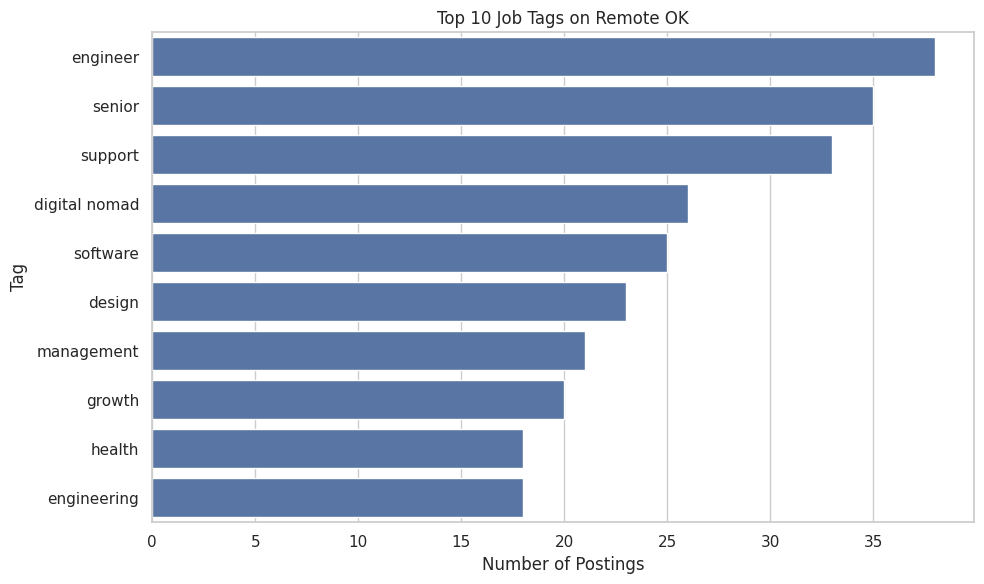

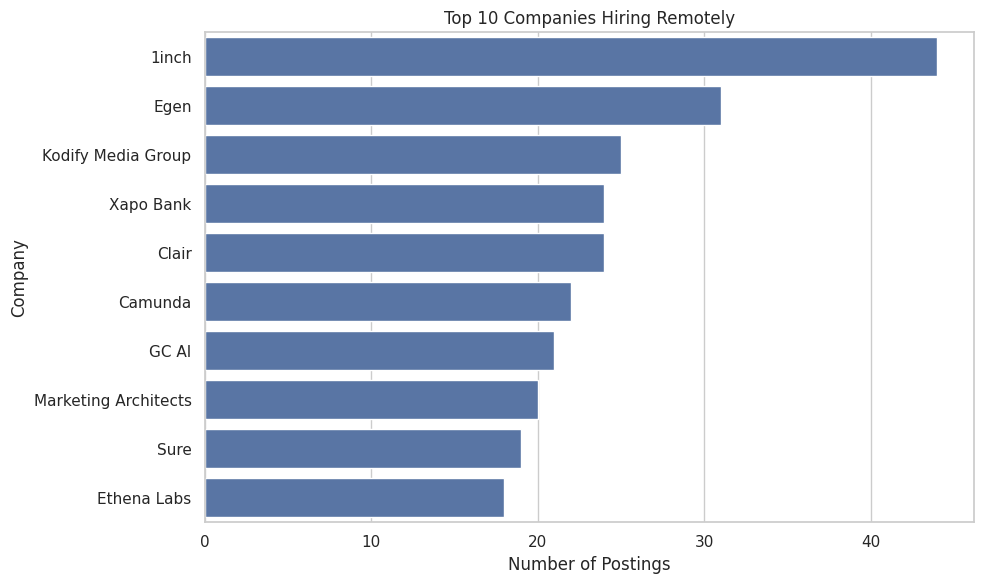

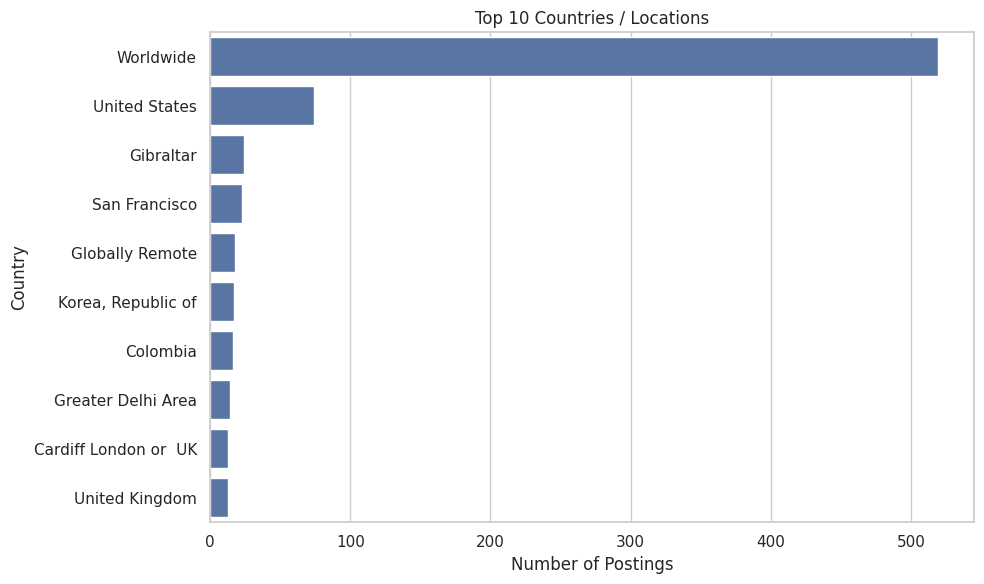

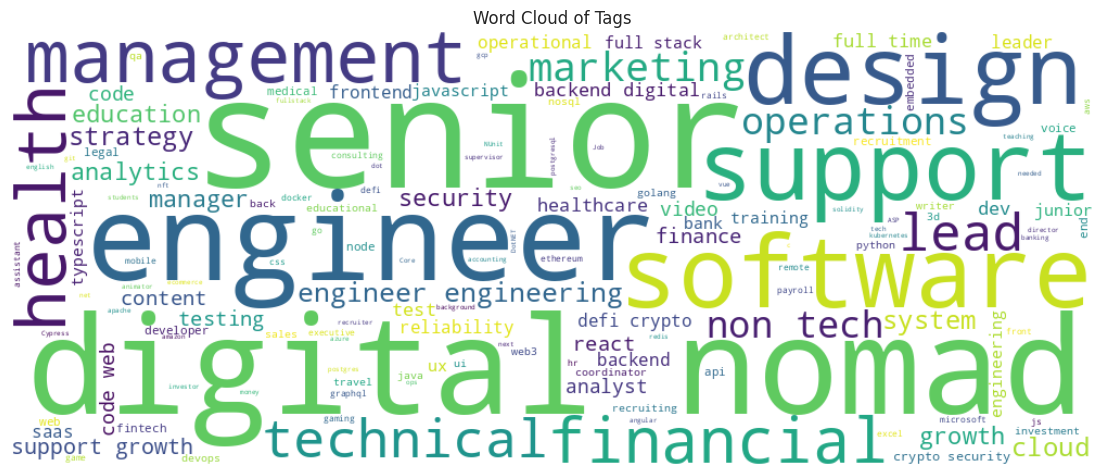

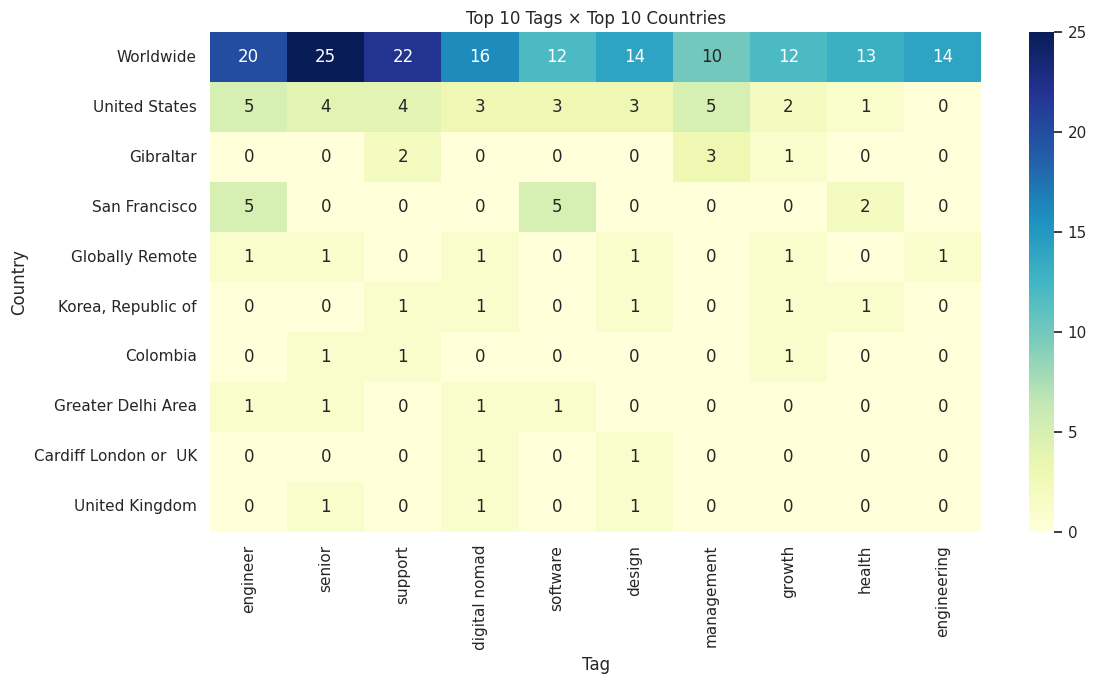

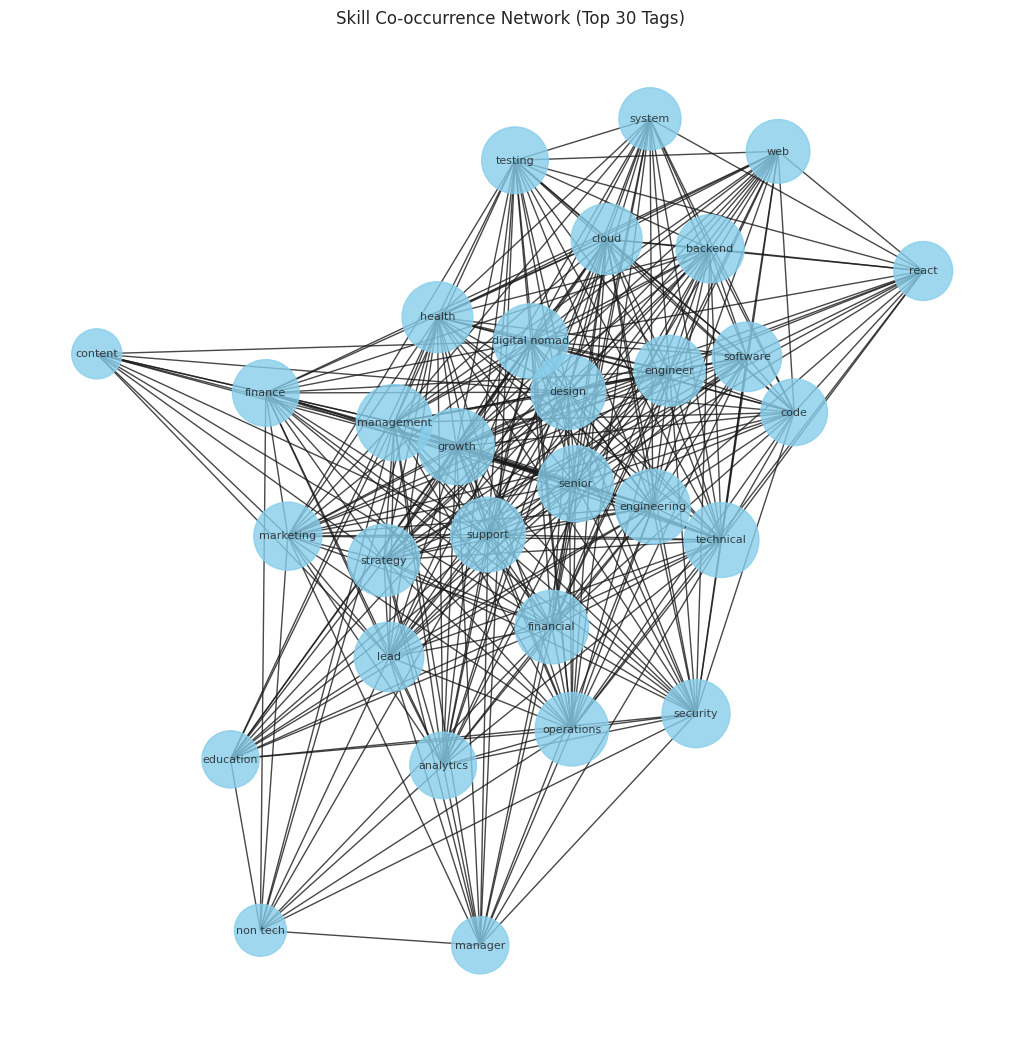

In [84]:
# Visualisation

#  Chart 1: Top 10 Job Tags on Remote OK
plt.figure(figsize=(10,6))
sns.barplot(x=df['tags'].value_counts().head(10).values,
            y=df['tags'].value_counts().head(10).index)
plt.title("Top 10 Job Tags on Remote OK")
plt.xlabel("Number of Postings")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()


# Chart 2: Top 10 Companies Hiring Remotely
plt.figure(figsize=(10,6))
sns.barplot(x=df['company'].value_counts().head(10).values,
            y=df['company'].value_counts().head(10).index)
plt.title("Top 10 Companies Hiring Remotely")
plt.xlabel("Number of Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

#  Chart 3: Top 10 Countries / Locations for Remote Jobs
plt.figure(figsize=(10,6))
sns.barplot(x=df['country'].value_counts().head(10).values,
            y=df['country'].value_counts().head(10).index)
plt.title("Top 10 Countries / Locations")
plt.xlabel("Number of Postings")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# Chart 4: Word Cloud of Job Tags
text = ' '.join(df['tags'].dropna().astype(str))
wc = WordCloud(width=1000, height=400, background_color='white').generate(text)

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tags")
plt.show()

#  Chart 5: Heatmap — Top 10 Tags × Top 10 Countries

pivot = pd.crosstab(df['country'], df['tags'])
top_countries = df['country'].value_counts().head(10).index
top_tags = df['tags'].value_counts().head(10).index
pivot = pivot.reindex(index=top_countries, columns=top_tags).fillna(0)

plt.figure(figsize=(12,7))
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title("Top 10 Tags × Top 10 Countries")
plt.xlabel("Tag")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


#  Chart 6: Treemap — Skill Popularity (Top 20 Tags)
top_tags = df['tags'].value_counts().head(20).reset_index()
top_tags.columns = ['Tag','Count']

fig = px.treemap(
    top_tags,
    path=['Tag'],
    values='Count',
    color='Count',
    color_continuous_scale='Tealgrn',
    title='Skill Popularity Treemap (Top 20 Tags)'
)
fig.show()


# Chart 7: Network Graph — Skill Co-occurrence (Top 30 Tags)

cooccurrence = {}
for _, group in df.groupby('id')['tags']:
    unique_tags = list(set(group))
    for a, b in itertools.combinations(unique_tags, 2):
        key = tuple(sorted((a, b)))
        cooccurrence[key] = cooccurrence.get(key, 0) + 1

top_tags_list = df['tags'].value_counts().head(30).index.tolist()
G = nx.Graph()
for (a, b), w in cooccurrence.items():
    if a in top_tags_list and b in top_tags_list and w > 1:
        G.add_edge(a, b, weight=w)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, k=0.4, seed=42)
node_sizes = [200 + nx.degree(G, n)*100 for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=node_sizes,
        node_color='skyblue', alpha=0.8, font_size=8)
plt.title("Skill Co-occurrence Network (Top 30 Tags)")
plt.show()


# Chart 8: World Map — Top 10 Countries by Job Count
countries = []
for name, count in df['country'].value_counts().head(10).items():
    try:
        if name == 'Worldwide':
            continue
        country = pycountry.countries.search_fuzzy(name)[0]
        countries.append({'country': name, 'iso': country.alpha_3, 'count': count})
    except:
        continue

cdf = pd.DataFrame(countries)
if not cdf.empty:
    fig = px.choropleth(
        cdf,
        locations='iso',
        color='count',
        hover_name='country',
        color_continuous_scale='Viridis',
        title='Top 10 Countries by Remote OK Job Postings'
    )
    fig.show()


In [83]:

#  SUMMARY

print("\n===  Insights Summary ===")

# Identify top skill (tag)
top_skill = df['tags'].value_counts().idxmax()
top_skill_count = df['tags'].value_counts().max()

# Identify top job position
top_job = df['position'].value_counts().idxmax()
top_job_count = df['position'].value_counts().max()

print(f"1️) Top required skill globally: {top_skill} ({top_skill_count} job postings)")
print(f"2️) Most frequently listed job title: {top_job} ({top_job_count} postings)")
print("3️) A few companies dominate remote hiring — key targets for applicants.")
print("4️) Tag-country heatmap shows regional skill specializations.")
print("5️) Co-occurrence network reveals skill bundles that often go together.")
print("6️) Treemap and world map make it easy to visualize hiring distribution.")

print("\n Analysis complete! All visualizations and insights generated successfully.")



===  Insights Summary ===
1️) Top required skill globally: engineer (38 job postings)
2️) Most frequently listed job title: Senior Software Engineer Backend (42 postings)
3️) A few companies dominate remote hiring — key targets for applicants.
4️) Tag-country heatmap shows regional skill specializations.
5️) Co-occurrence network reveals skill bundles that often go together.
6️) Treemap and world map make it easy to visualize hiring distribution.

 Analysis complete! All visualizations and insights generated successfully.
